In [1]:
from pathlib import Path
from puprisa.core.pps import PPS
import matplotlib.pyplot as plt

In [2]:
# %load_ext autoreload
# %autoreload 2

# Example usage of PPS functionality

Import DukeScan file

In [3]:
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
filename = ROOT / "data" / "melanin_DS_CH1.tif"    
stack = PPS.load(filename)

## Visualization
Show plot of average TA curve and projected stack

<Axes: title={'center': 'melanin_DS_CH1.tif'}, xlabel='Time delay (ps)', ylabel='Average signal (a.u.)'>

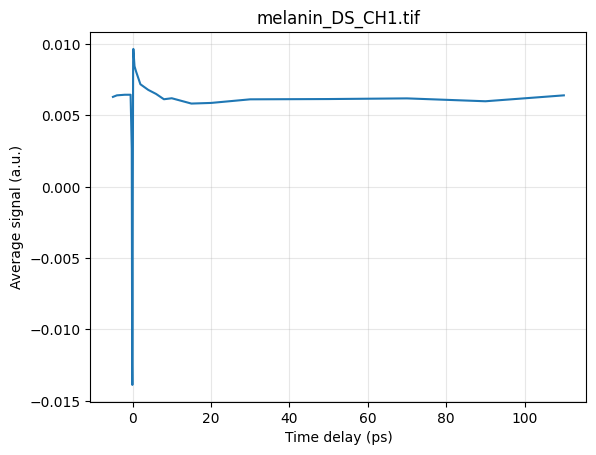

In [4]:
stack.plot_average_curve()

<Axes: title={'center': 'melanin_DS_CH1.tif - projection'}>

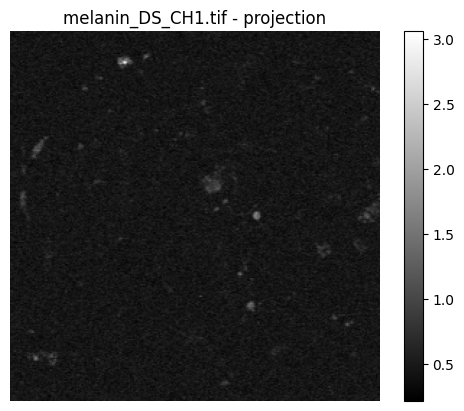

In [5]:
stack.plot_projection()

## Processing

### Subtracting the mean of the first few images and downsampling

<Axes: title={'center': 'melanin_DS_CH1.tif'}, xlabel='Time delay (ps)', ylabel='Average signal (a.u.)'>

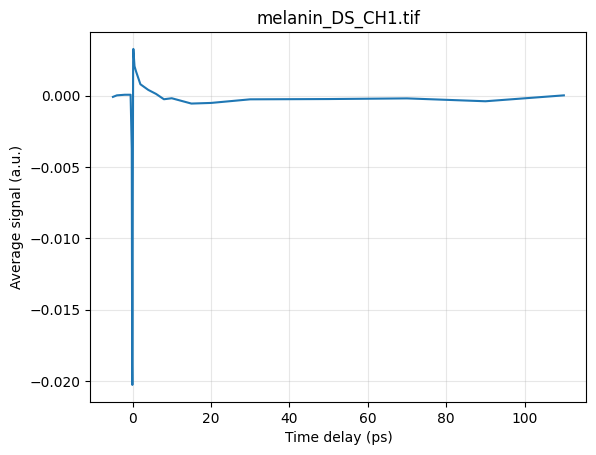

In [6]:
stack.apply_background_subtraction(indices=range(3), pixelwise=True)
stack.plot_average_curve()

<Axes: title={'center': 'melanin_DS_CH1.tif - projection'}>

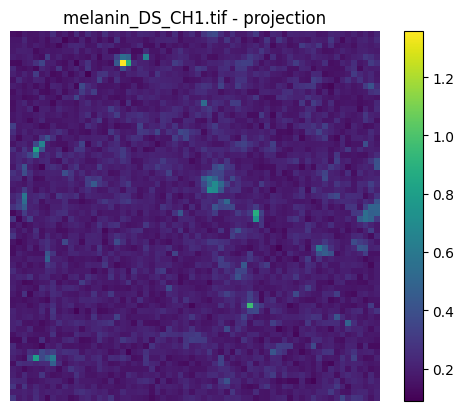

In [7]:
downsampled_stack = stack.downsample(factor=4)
downsampled_stack.plot_projection(colormap = "viridis")

### intensity threshold

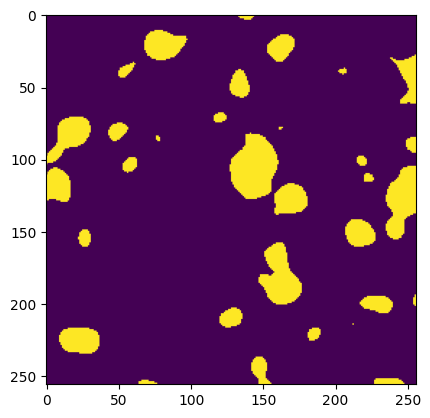

In [8]:
stack.create_mask_from_threshold()
plt.imshow(stack.mask)
plt.show()

<Axes: title={'center': 'melanin_DS_CH1.tif - projection'}>

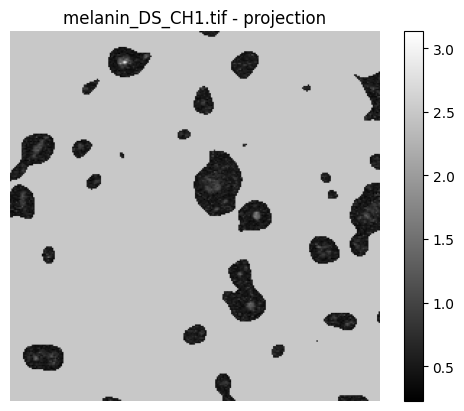

In [9]:
stack.plot_projection()

### derive substacks

In [10]:
substacks = stack.substacks(128)
print(f"Number of substacks: {len(substacks)}")

Number of substacks: 4


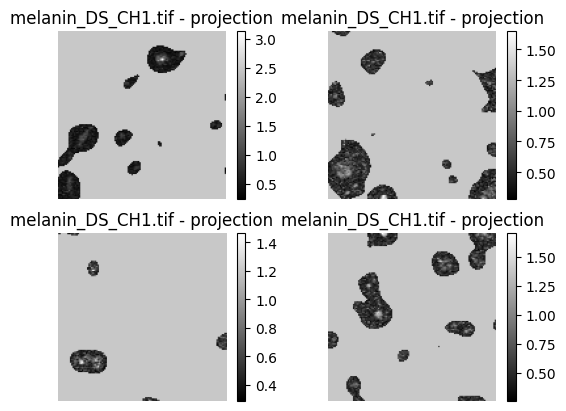

In [11]:
fig, axes = plt.subplots(2, 2)
axes = axes.flatten()
for i, substack in enumerate(substacks):
    substack.plot_projection(ax=axes[i])

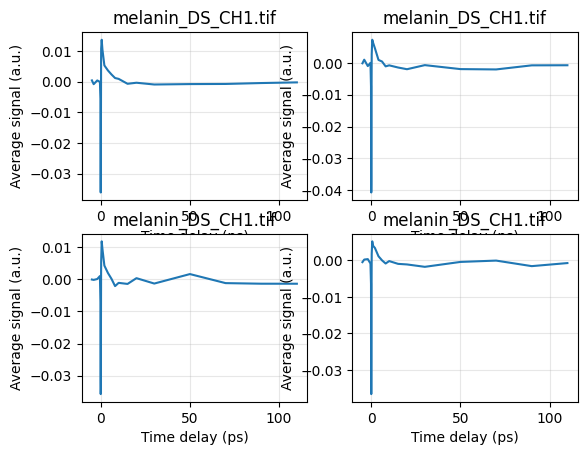

In [12]:
fig, ax = plt.subplots(2, 2)
ax = ax.flatten()
for i, substack in enumerate(substacks):
    substack.plot_average_curve(ax=ax[i])

### Phasor

<Axes: title={'center': 'Phasor @ 0.25 THz'}, xlabel='g', ylabel='s'>

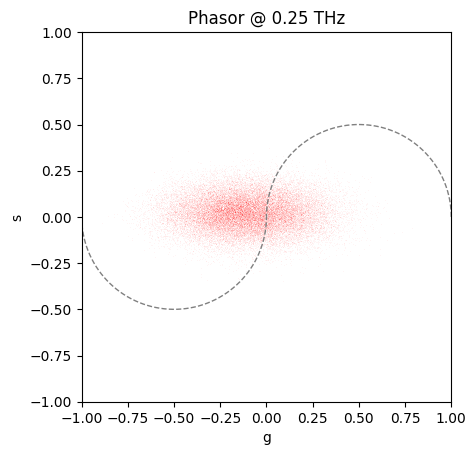

In [13]:
stack.plot_phasor(color_hex = "#FF0000", freq = 0.25, use_mask = False)